# 🛰️ Notebook 3: Earth Observation UQ with EuroSAT

We now apply everything learned to a **real-world remote sensing problem**.

This notebook might take a while on a machine without GPU. 

## Scenario
1. Train a CNN on **clean EuroSAT** satellite images
2. Generate **synthetic cloud corruption** at test time
3. Show how clouds cause the model to **fail silently** (high confidence, wrong prediction)
4. Apply UQ methods to flag uncertain predictions
5. Train with cloud augmentation → learn **aleatoric uncertainty** from clouds

## Dataset: EuroSAT
- 27,000 Sentinel-2 RGB images (64×64 px) (we work with a subset of it)
- 10 land-use classes: AnnualCrop, Forest, HerbaceousVegetation, Highway,
  Industrial, Pasture, PermanentCrop, Residential, River, SeaLake

---


In [1]:
!pip install torchgeo
!pip install satellite_cloud_generator

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import transforms
import timm
import warnings; warnings.filterwarnings("ignore")
import os 
import torch
import numpy as np
from torch.utils.data import Subset
from torchgeo.datasets import EuroSAT as TGEuroSAT

SEED = 999
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BLUE="#4C72B0"; ORANGE="#DD8452"; GREEN="#55A868"
RED="#C44E52"; PURPLE="#8172B2"; GRAY="#BBBBBB"
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,
                     "axes.spines.right":False,"font.size":11})

EUROSAT_CLASSES = [
    "AnnualCrop","Forest","HerbaceousVeg","Highway",
    "Industrial","Pasture","PermanentCrop","Residential","River","SeaLake"
]
N_CLASSES = len(EUROSAT_CLASSES)

print(f"Device: {device}")


# ─── Cloud experiment configuration ──────────────────────────────────────────
CLOUD_FRAC       = 0.05    # fraction of *training* examples that are cloudy
CLOUD_COV_TRAIN  = .9   # max cloud coverage used for training augmentation
CLOUD_COV_EVAL   = .9   # fixed cloud coverage for the 100%-cloudy eval set
CLOUD_CACHE_DIR  = './data/EUROSAT/cloud_cache'
os.makedirs(CLOUD_CACHE_DIR, exist_ok=True)
print(f"Cloud config: train_frac={CLOUD_FRAC}  cov_train={CLOUD_COV_TRAIN}  cov_eval={CLOUD_COV_EVAL}")


Device: cuda
Cloud config: train_frac=0.05  cov_train=0.9  cov_eval=0.9


---
## 1  Load EuroSAT via torchgeo

[torchgeo](https://github.com/microsoft/torchgeo) is the standard library for
geospatial deep learning. Its `EuroSAT` dataset class loads the **full
13-band multispectral Sentinel-2** version, complete with official train/val/test
splits and per-band normalisation statistics.

We select bands **B04 (Red), B03 (Green), B02 (Blue)** for this notebook.

> **Sentinel-2 band layout (0-indexed in torchgeo)**
>
> | Index | Band | Wavelength |
> |-------|------|------------|
> | 0 | B01 — Coastal aerosol | 443 nm |
> | 1 | B02 — Blue            | 490 nm |
> | 2 | B03 — Green           | 560 nm |
> | 3 | B04 — Red             | 665 nm |
> | 4 | B05 — Red Edge        | 705 nm |
> | ... | ... | ... |

> 💡 The dataset will be downloaded to ./data/EUROSAT` on first run.


In [2]:
# --- Band selection and normalisation ---
# torchgeo EuroSAT returns 13-band Sentinel-2 images as (13, 64, 64) float tensors,
# in order B01,B02,B03,B04,... Pixel values are uint16 reflectance (~0-10000 scale).
# We use the 3 RGB bands for ResNet-18 compatibility.
RGB_IDX = [3, 2, 1]   # B04=Red, B03=Green, B02=Blue (0-indexed into the 13 bands)

# Per-channel mean/std for the RGB bands. The EuroSAT *dataset* class has no
# .mean/.std (those live in torchgeo's EuroSATDataModule), so in practice the
# fallback below is used — the try/except just keeps it robust across versions.
try:
    _mean_all = TGEuroSAT.mean
    _std_all  = TGEuroSAT.std
    MEAN = [_mean_all[i].item() for i in RGB_IDX]
    STD  = [_std_all[i].item()  for i in RGB_IDX]
except AttributeError:
    MEAN = [1370.19, 1184.36, 1120.55]
    STD  = [ 322.04,  354.22,  364.76]


class RGBWrapper(torch.utils.data.Dataset):
    """Wraps a torchgeo EuroSAT dataset:
       - selects RGB bands
       - normalises to zero mean / unit std
       - returns (image_tensor, label_int) tuples compatible with DataLoader
    """
    def __init__(self, tg_ds, augment=False):
        self.ds      = tg_ds
        self.augment = augment
        self.m = torch.tensor(MEAN, dtype=torch.float32)[:, None, None]
        self.s = torch.tensor(STD,  dtype=torch.float32)[:, None, None]

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        img    = sample['image'][RGB_IDX].float()     # (3, 64, 64)
        img    = (img - self.m) / self.s              # normalise
        if self.augment:
            if torch.rand(()) > .5: img = torch.flip(img, [-1])
            if torch.rand(()) > .5: img = torch.flip(img, [-2])
        label = sample['label'].long()
        return img, label


def denorm(t):
    """Reverse normalisation for display; scale to [0, 1] for imshow."""
    m = torch.tensor(MEAN, dtype=torch.float32)[None, :, None, None]
    s = torch.tensor(STD,  dtype=torch.float32)[None, :, None, None]
    t = t.cpu() * s + m
    t = t / 3000.0                                    # Sentinel-2 reflectance -> ~[0, 1]
    return t.clamp(0, 1)


def balanced_subset(ds, per_class, seed=42):
    """Return a Subset with up to `per_class` examples from each class."""
    targets = np.asarray(ds.targets)                  # inherited from torchvision ImageFolder
    rng = np.random.default_rng(seed)
    idxs = []
    for c in np.unique(targets):
        cls_idx = np.where(targets == c)[0]
        take    = min(per_class, len(cls_idx))
        idxs.extend(rng.choice(cls_idx, size=take, replace=False).tolist())
    return Subset(ds, sorted(idxs))


# --- Load EuroSAT, subset training to 200 examples per class ---
PER_CLASS = 300
SYNTHETIC = False
try:
    _raw_train = TGEuroSAT(root='./data/EUROSAT', split='train', download=True)
    _raw_test  = TGEuroSAT(root='./data/EUROSAT', split='test',  download=True)

    train_subset = balanced_subset(_raw_train, PER_CLASS, seed=42)   # 300 * 10 classes
    train_ds = RGBWrapper(train_subset, augment=True)
    test_ds  = RGBWrapper(_raw_test,    augment=False)

    print('EuroSAT (torchgeo, multispectral) loaded successfully')
    print(f'  Train: {len(train_ds)} ({PER_CLASS}/class x {len(_raw_train.classes)} classes)'
          f'   Test: {len(test_ds)}')
    print(f'  Classes: {_raw_train.classes}')
    print(f'  RGB band stats (mean/std): {[round(m,1) for m in MEAN]} / {[round(s,1) for s in STD]}')
except Exception as e:
    SYNTHETIC = True
    print(f'torchgeo EuroSAT load failed: {type(e).__name__}: {e}')
    raise

EuroSAT (torchgeo, multispectral) loaded successfully
  Train: 3000 (300/class x 10 classes)   Test: 5400
  Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  RGB band stats (mean/std): [1370.2, 1184.4, 1120.5] / [322.0, 354.2, 364.8]


In [3]:
# ─── Step 1: collect all train/test images into tensors ──────────────────────
# We do this once so that:
#   (a) cloud caches can be pre-generated with fixed seeds
#   (b) MixedCloudDataset can index images directly without re-hitting disk

print("Collecting train/test tensors…")
_loader = DataLoader(train_ds, batch_size=32, shuffle=False, num_workers=8, drop_last=True)
_train_imgs, _train_lbls = [], []
for xb, yb in _loader:
    _train_imgs.append(xb); _train_lbls.append(yb)
train_imgs_clean = torch.cat(_train_imgs)   # [N_train, 3, 64, 64]  normalised
train_lbls_clean = torch.cat(_train_lbls)

_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=8, drop_last=False)
_test_imgs, _test_lbls = [], []
for xb, yb in _loader:
    _test_imgs.append(xb); _test_lbls.append(yb)
test_imgs_clean = torch.cat(_test_imgs)     # [N_test, 3, 64, 64]
test_lbls_clean = torch.cat(_test_lbls)
print(f"  Train: {train_imgs_clean.shape}  Test: {test_imgs_clean.shape}")


# ─── Step 2: generate (or load) cloud caches ─────────────────────────────────
# Images are processed in batches; each batch uses seed = SEED + batch_start_idx
# so the result is identical across runs and machines.

def make_cloud_cache(imgs, cache_path, max_cov, batch_size=64):
    """
    Generate cloudy versions of every image in `imgs` [N, C, H, W].
    Saves result to cache_path and returns the cloudy tensor.
    If cache already exists, loads and returns it directly.
    """
    if os.path.exists(cache_path):
        print(f"  Cache found  → {cache_path}")
        return torch.load(cache_path, weights_only=True)

    print(f"  Generating   → {cache_path}  (max_cov={max_cov})")
    batches = []
    for start in range(0, len(imgs), batch_size):
        batch = imgs[start : start + batch_size]
        # Deterministic per-batch seed: same start index → same clouds
        cloudy = add_clouds(batch, max_cov=max_cov, seed=SEED + start)
        batches.append(cloudy.cpu())
        if start % 256 == 0:
            print(f"    {start}/{len(imgs)}", end="\r")
    result = torch.cat(batches)
    torch.save(result, cache_path)
    print(f"  Saved {len(result)} images → {cache_path}     ")
    return result

print("Cache generation deferred to dataloader cell (requires add_clouds).")
print("Tensor collection complete ✓")


  Train: torch.Size([2976, 3, 64, 64])  Test: torch.Size([5400, 3, 64, 64])
Cache generation deferred to dataloader cell (requires add_clouds).
Tensor collection complete ✓


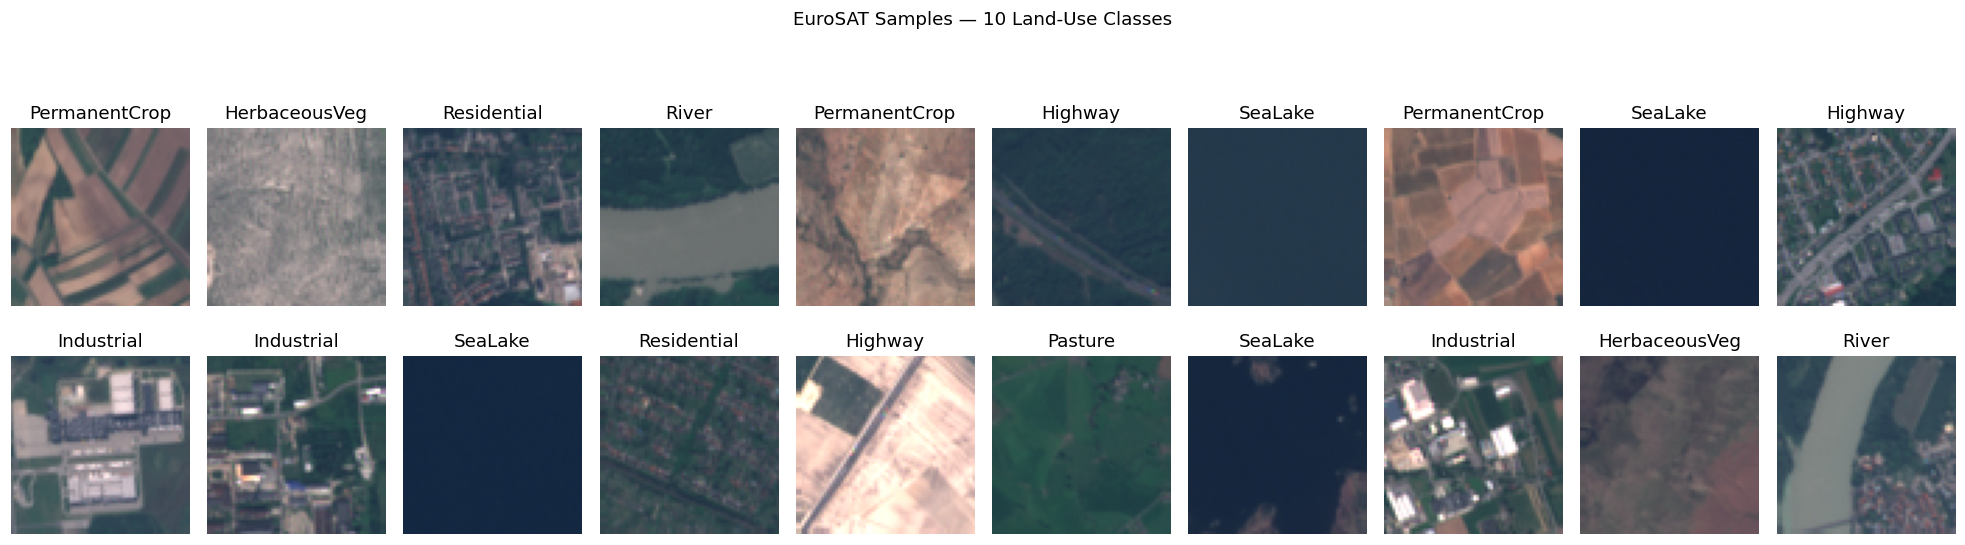

In [4]:
# ─── Visualise sample images ───────────────────────────────────────────────────
train_loader      = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=8)
test_loader_clean = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=8)

imgs_sample, lbl_sample = next(iter(train_loader))
if not SYNTHETIC:
    imgs_dn = denorm(imgs_sample[:20])
else:
    imgs_dn = imgs_sample[:20].clamp(0,1)

fig, axes = plt.subplots(2, 10, figsize=(18, 5))
for i, (ax, img, lbl) in enumerate(zip(axes.flatten(), imgs_dn, lbl_sample)):
    ax.imshow(img.permute(1,2,0).numpy())
    ax.set_title(EUROSAT_CLASSES[lbl.item()], fontsize=12)
    ax.axis("off")
plt.suptitle("EuroSAT Samples — 10 Land-Use Classes", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()


---
## 2  Train a Baseline CNN (clean images)

We use a **MobileNetV3-Small** pre-trained on ImageNet and fine-tune it for EuroSAT.

In [5]:
# ─── MobileNetV3-Small (timm) ────────────────────────────────────────────────
# timm's MobileNetV3 supports drop_rate for MC Dropout:
#   drop_rate applies dropout before the final classifier layer.
#   Calling model.train() at inference keeps it active (MC Dropout).
def make_model(n_cls=N_CLASSES, pretrained=True, dropout=0.1):
    """Create a MobileNetV3-Small with a custom head for n_cls classes."""
    m = timm.create_model(
        'mobilenetv3_small_100',
        pretrained=pretrained,
        num_classes=n_cls,
        drop_rate=dropout,       # dropout before final FC
    )
    return m


def train_model(model, loader, n_epochs=30, lr=0.0001, verbose=True):
    opt  = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for ep in range(n_epochs):
        model.train()
        correct, total, ep_loss = 0, 0, 0.
        for i, (xb, yb) in enumerate(loader):
            print(f"Epoch [{ep+1:2d}/{n_epochs}] - Batch [{i+1}/{len(loader)}] ...       ", end="\r")
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)                 # single forward, reused for loss + acc
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            correct += (logits.argmax(-1) == yb).sum().item()
            total   += len(yb)
            ep_loss += loss.item()
            del xb, yb, logits, loss
        if verbose and (ep % 2 == 0 or ep == n_epochs - 1):
            print(f"  Epoch {ep+1:2d}/{n_epochs}  loss={ep_loss/len(loader):.3f}                "
                  f"acc={correct/total*100:.1f}%")


baseline_cnn = make_model(pretrained=True).to(device)
n_params = sum(p.numel() for p in baseline_cnn.parameters() if p.requires_grad)
print(f"MobileNetV3-Small: {n_params/1e6:.2f}M parameters")
print("Training baseline MobileNet ...")
train_model(baseline_cnn, train_loader, n_epochs=30)


# ─── Evaluate on clean test set ───────────────────────────────────────────────
def eval_model(model, loader):
    model.eval()
    all_correct, all_logits, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            all_correct.append((logits.argmax(-1) == yb).cpu())
            all_logits.append(logits.cpu())
            all_labels.append(yb.cpu())
    return (torch.cat(all_correct).float().mean().item(),
            torch.cat(all_logits),
            torch.cat(all_labels))


clean_acc, clean_logits, clean_labels = eval_model(baseline_cnn, test_loader_clean)
print(f"\nBaseline MobileNet — Clean test accuracy: {clean_acc*100:.1f}%")

MobileNetV3-Small: 1.53M parameters
Training baseline MobileNet ...
  Epoch  1/30  loss=4.501                acc=44.4%
  Epoch  3/30  loss=1.479                acc=75.5%
  Epoch  5/30  loss=0.820                acc=83.2%
  Epoch  7/30  loss=0.551                acc=87.1%
  Epoch  9/30  loss=0.482                acc=89.1%
  Epoch 11/30  loss=0.301                acc=92.3%
  Epoch 13/30  loss=0.260                acc=93.6%
  Epoch 15/30  loss=0.182                acc=94.8%
  Epoch 17/30  loss=0.213                acc=94.6%
  Epoch 19/30  loss=0.136                acc=95.9%
  Epoch 21/30  loss=0.167                acc=95.5%
  Epoch 23/30  loss=0.140                acc=96.2%
  Epoch 25/30  loss=0.081                acc=97.3%
  Epoch 27/30  loss=0.083                acc=97.6%
  Epoch 29/30  loss=0.103                acc=97.4%
  Epoch 30/30  loss=0.087                acc=97.7%

Baseline MobileNet — Clean test accuracy: 90.6%


---
## 3  Synthetic Cloud Generation

We simulate clouds using **layered Gaussian blobs** + **brightness overlay**.

```
Cloud formula:
  cloud_mask   = Gaussian(μ=random, σ=random) × intensity
  cloudy_image = image × (1 - cloud_mask) + white × cloud_mask
```

Cloud coverage levels: **Light** (10–30%), **Medium** (30–60%), **Heavy** (60–85%)


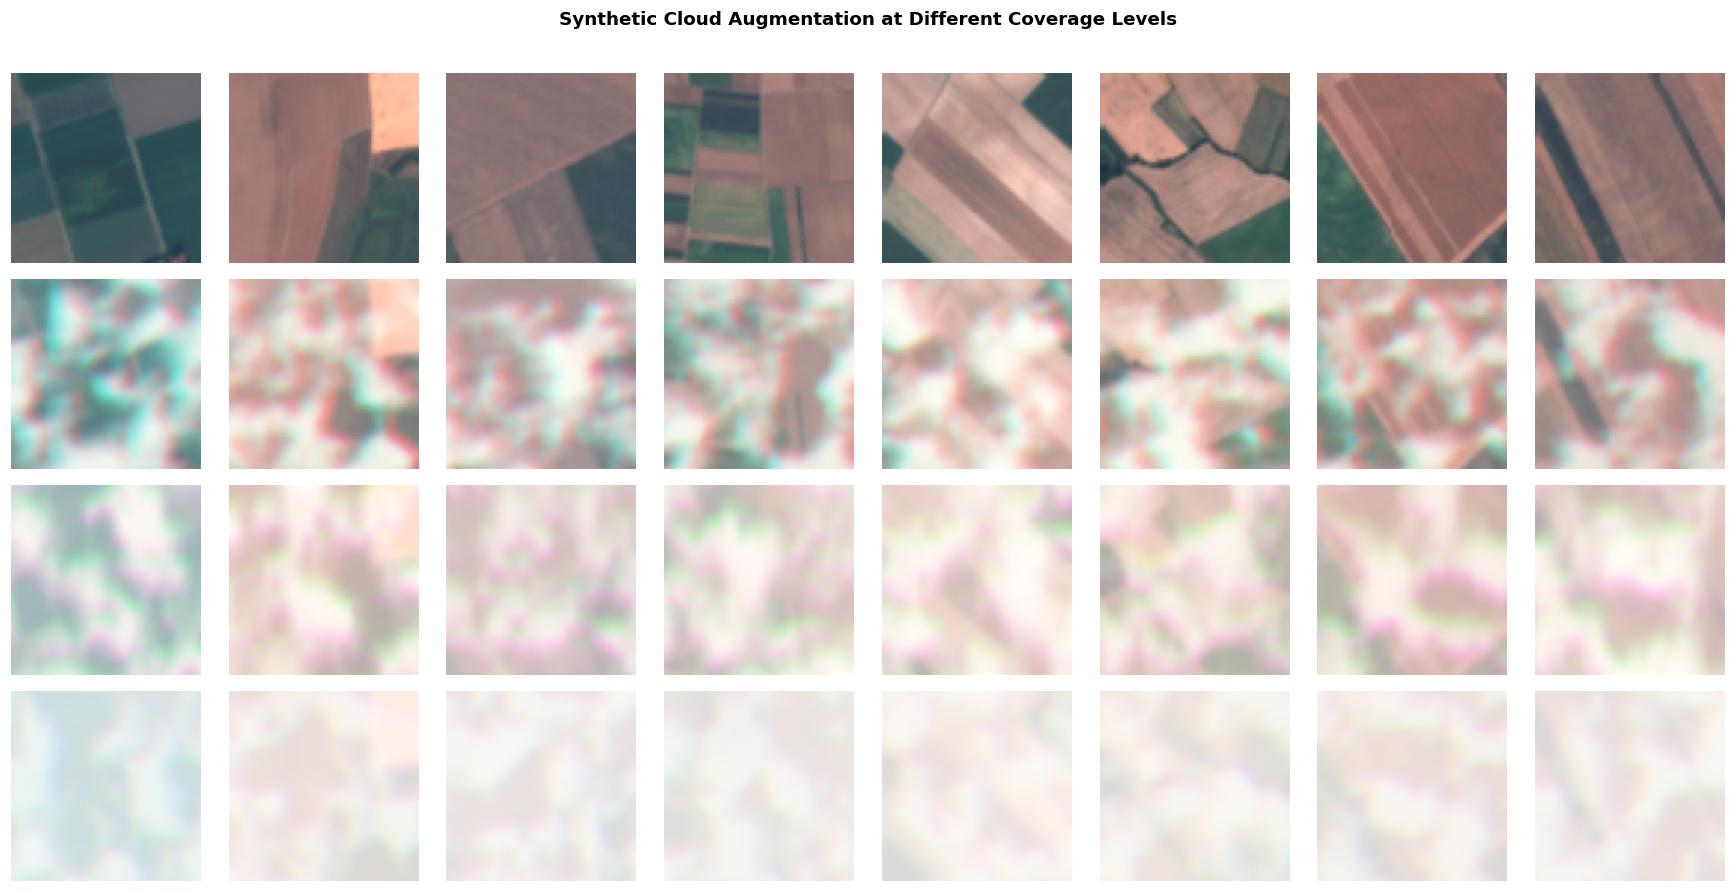

In [6]:
from satellite_cloud_generator import add_cloud

# ─── Normalisation helpers ────────────────────────────────────────────────────
def _get_norm_tensors():
    m = torch.tensor(MEAN, dtype=torch.float32)[None, :, None, None]
    s = torch.tensor(STD,  dtype=torch.float32)[None, :, None, None]
    return m, s

def add_clouds(imgs, max_cov=0.5, seed=None):
    """
    Add clouds to a batch of *normalised* images [B, C, H, W].
    Converts to [0,1] internally, applies cloud generation with the original
    parameterisation, then re-normalises back to Sentinel-2 stats.
    """
    if seed is not None:
        torch.manual_seed(seed)

    # 1. denorm to [0, 1]
    imgs_01 = denorm(imgs)

    # 2. apply cloud generator — original parameterisation preserved
    cloudy_01, _ = add_cloud(
        imgs_01,
        min_lvl=max_cov,
        max_lvl=1,
        const_scale=True,
        decay_factor=1.0,
        clear_threshold=[0.0, 0.2],
        locality_degree=1,
        cloud_color=True,
        channel_offset=2,
        blur_scaling=2,
        return_cloud=True,
    )

    # 3. re-normalise back to model input space
    m, s = _get_norm_tensors()
    cloudy_norm = (cloudy_01.cpu() * 3000.0 - m) / s
    return cloudy_norm

# ─── Visualise cloud generation ───────────────────────────────────────────────
imgs_clean, labels_vis = next(iter(test_loader_clean))
imgs_light  = add_clouds(imgs_clean, max_cov=0.30, seed=10)
imgs_medium = add_clouds(imgs_clean, max_cov=0.60, seed=20)
imgs_heavy  = add_clouds(imgs_clean, max_cov=0.85, seed=30)

def show_row(axes, imgs, row_label):
    """Display a row of (normalised) images after denorm."""
    imgs_dn = denorm(imgs[:8]) if not SYNTHETIC else imgs[:8].clamp(0, 1)
    for j, ax in enumerate(axes):
        ax.imshow(imgs_dn[j].permute(1, 2, 0).numpy().clip(0, 1))
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(row_label, fontsize=9, labelpad=5)

fig, all_axes = plt.subplots(4, 8, figsize=(16, 8))
for i, (imgs, lbl) in enumerate([
    (imgs_clean,  "Clean"),
    (imgs_light,  "Light (30%)"),
    (imgs_medium, "Medium (60%)"),
    (imgs_heavy,  "Heavy (85%)"),
]):
    show_row(all_axes[i], imgs, lbl)

for ax in all_axes.flatten():
    ax.axis("off")

plt.suptitle("Synthetic Cloud Augmentation at Different Coverage Levels",
             fontsize=12, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


In [7]:
# ─── Step 3: build cloud caches now that add_clouds is defined ───────────────
train_cache_path = f"{CLOUD_CACHE_DIR}/train_cloudy_cov{int(CLOUD_COV_TRAIN*100)}.pt"
test_cache_path  = f"{CLOUD_CACHE_DIR}/test_cloudy_cov{int(CLOUD_COV_EVAL*100)}.pt"

print("Building / loading cloud caches…")
train_imgs_cloudy = make_cloud_cache(train_imgs_clean, train_cache_path, CLOUD_COV_TRAIN)
test_imgs_cloudy  = make_cloud_cache(test_imgs_clean,  test_cache_path,  CLOUD_COV_EVAL)
print("Cloud caches ready ✓")


# ─── Step 4: dataset classes ──────────────────────────────────────────────────
class MixedCloudDataset(torch.utils.data.Dataset):
    """
    Serves a deterministic mix of clean and pre-generated cloudy images.
    The clean/cloudy assignment is fixed at construction time (by seed),
    so every epoch uses the exact same images — fully reproducible.

    cloud_frac: fraction of indices served as cloudy.
    """
    def __init__(self, clean_imgs, clean_lbls, cloudy_imgs,
                 cloud_frac=CLOUD_FRAC, seed=SEED, augment=True):
        self.clean_imgs  = clean_imgs
        self.clean_lbls  = clean_lbls
        self.cloudy_imgs = cloudy_imgs
        self.augment     = augment
        rng = np.random.default_rng(seed)
        self.is_cloudy = rng.random(len(clean_imgs)) < cloud_frac
        n_cloudy = self.is_cloudy.sum()
        print(f"  MixedCloudDataset: {n_cloudy}/{len(clean_imgs)} cloudy "
              f"({n_cloudy/len(clean_imgs)*100:.1f}%)")

    def __len__(self): return len(self.clean_imgs)

    def __getitem__(self, idx):
        lbl = self.clean_lbls[idx]
        img = self.cloudy_imgs[idx] if self.is_cloudy[idx] else self.clean_imgs[idx]
        if self.augment:
            if torch.rand(()) > 0.5: img = torch.flip(img, [-1])
            if torch.rand(()) > 0.5: img = torch.flip(img, [-2])
        return img, lbl


class TensorDS(torch.utils.data.Dataset):
    """Thin wrapper so a tensor pair works with DataLoader."""
    def __init__(self, imgs, lbls):
        self.imgs = imgs; self.lbls = lbls
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx): return self.imgs[idx], self.lbls[idx]


# ─── Step 5: build all loaders ────────────────────────────────────────────────
mixed_ds = MixedCloudDataset(train_imgs_clean, train_lbls_clean, train_imgs_cloudy)
mixed_loader = DataLoader(mixed_ds, batch_size=64, shuffle=True, num_workers=0, drop_last=True)

# 100% clean test set (original)
test_loader_clean  = DataLoader(TensorDS(test_imgs_clean,  test_lbls_clean),
                                 batch_size=64, shuffle=False, num_workers=0, drop_last=False)
# 100% cloudy test set (pre-generated, fixed seeds)
test_loader_cloudy = DataLoader(TensorDS(test_imgs_cloudy, test_lbls_clean),
                                 batch_size=64, shuffle=False, num_workers=0, drop_last=False)

# Keep original train_loader for baseline visualisation
train_loader = DataLoader(TensorDS(train_imgs_clean, train_lbls_clean),
                           batch_size=64, shuffle=True, num_workers=0, drop_last=True)

print(f"\nDataloaders ready:")
print(f"  mixed_loader      : {len(mixed_ds)} samples "
      f"({CLOUD_FRAC:.0%} cloudy / {1-CLOUD_FRAC:.0%} clean)")
print(f"  test_loader_clean : {len(test_imgs_clean)} samples (100% clean)")
print(f"  test_loader_cloudy: {len(test_imgs_cloudy)} samples "
      f"(100% cloudy @ cov={CLOUD_COV_EVAL:.0%})")


Building / loading cloud caches…
  Cache found  → ./data/EUROSAT/cloud_cache/train_cloudy_cov90.pt
  Cache found  → ./data/EUROSAT/cloud_cache/test_cloudy_cov90.pt
Cloud caches ready ✓
  MixedCloudDataset: 136/2976 cloudy (4.6%)

Dataloaders ready:
  mixed_loader      : 2976 samples (5% cloudy / 95% clean)
  test_loader_clean : 5400 samples (100% clean)
  test_loader_cloudy: 3000 samples (100% cloudy @ cov=90%)


---
## 4  Effect of Clouds on the Baseline CNN

Our baseline was trained on **only clear images**. Hence, it has **no awareness of clouds**.

  Cloud=0%  Acc=90.6%  Conf=0.969  Entropy=0.080
  Cloud=15%  Acc=21.1%  Conf=0.809  Entropy=0.501
  Cloud=30%  Acc=20.2%  Conf=0.816  Entropy=0.488
  Cloud=45%  Acc=17.8%  Conf=0.835  Entropy=0.431
  Cloud=60%  Acc=12.7%  Conf=0.894  Entropy=0.272
  Cloud=75%  Acc=12.1%  Conf=0.907  Entropy=0.231
  Cloud=85%  Acc=14.4%  Conf=0.955  Entropy=0.106


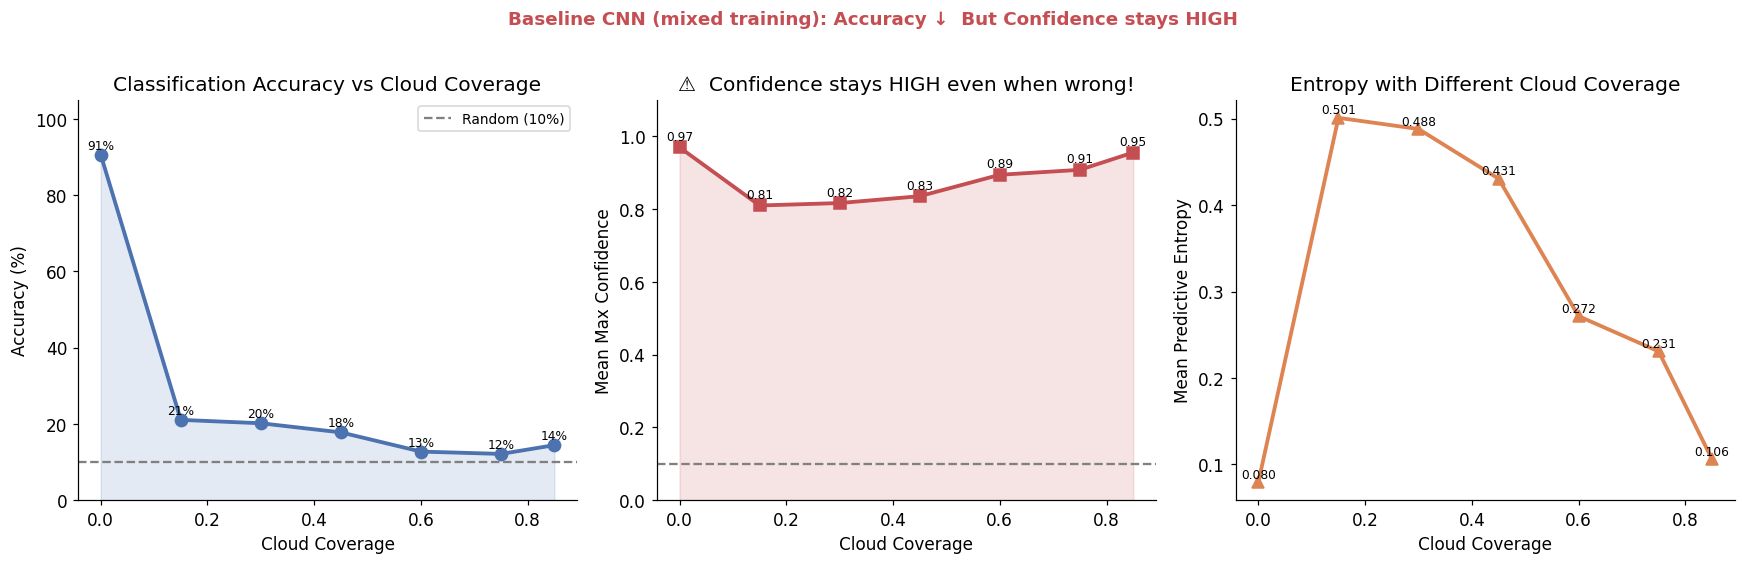


Baseline — Clean vs 100% Cloudy test sets:
  clean     Acc=90.6%  Conf=0.969  Entropy=0.080
  cloudy    Acc=9.5%  Conf=0.963  Entropy=0.087


In [8]:
# ─── Evaluate at different cloud levels (sweep) ──────────────────────────────
cloud_levels = [0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.85]

accs, confs, entropies = [], [], []
baseline_cnn.eval()

for cov in cloud_levels:
    all_corr, all_conf, all_ent = [], [], []
    for xb, yb in test_loader_clean:
        if cov > 0:
            xb = add_clouds(xb, max_cov=cov, seed=42)
        xb, yb = xb.to(device), yb
        with torch.no_grad():
            probs = F.softmax(baseline_cnn(xb), dim=-1).cpu()
        preds = probs.argmax(-1)
        all_corr.append((preds == yb).float().cpu())
        all_conf.append(probs.max(-1).values.cpu())
        all_ent.append(-(probs * probs.log().clamp(-20)).sum(-1).cpu())
    accs.append(torch.cat(all_corr).mean().item())
    confs.append(torch.cat(all_conf).mean().item())
    entropies.append(torch.cat(all_ent).mean().item())
    print(f"  Cloud={cov:.0%}  Acc={accs[-1]*100:.1f}%  Conf={confs[-1]:.3f}  Entropy={entropies[-1]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(cloud_levels, [a*100 for a in accs], "o-", color=BLUE, lw=2.5, ms=8)
ax.fill_between(cloud_levels, 0, [a*100 for a in accs], alpha=0.15, color=BLUE)
ax.set(xlabel="Cloud Coverage", ylabel="Accuracy (%)",
       title="Classification Accuracy vs Cloud Coverage", ylim=(0, 105))
ax.axhline(1/N_CLASSES*100, color="gray", ls="--", label=f"Random ({100/N_CLASSES:.0f}%)")
ax.legend(fontsize=9)
for x, a in zip(cloud_levels, accs):
    ax.text(x, a*100+1.5, f"{a*100:.0f}%", ha="center", fontsize=8)

ax = axes[1]
ax.plot(cloud_levels, confs, "s-", color=RED, lw=2.5, ms=8)
ax.fill_between(cloud_levels, 0, confs, alpha=0.15, color=RED)
ax.set(xlabel="Cloud Coverage", ylabel="Mean Max Confidence",
       title="⚠  Confidence stays HIGH even when wrong!", ylim=(0, 1.1))
ax.axhline(1/N_CLASSES, color="gray", ls="--")
for x, c in zip(cloud_levels, confs):
    ax.text(x, c+0.02, f"{c:.2f}", ha="center", fontsize=8)

ax = axes[2]
ax.plot(cloud_levels, entropies, "^-", color=ORANGE, lw=2.5, ms=8)
ax.set(xlabel="Cloud Coverage", ylabel="Mean Predictive Entropy",
       title="Entropy with Different Cloud Coverage")
for x, e in zip(cloud_levels, entropies):
    ax.text(x, e+0.005, f"{e:.3f}", ha="center", fontsize=8)

plt.suptitle("Baseline CNN (mixed training): Accuracy ↓  But Confidence stays HIGH",
             color=RED, fontweight="bold", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ─── Clean vs 100% Cloudy: head-to-head comparison ───────────────────────────
print("\nBaseline — Clean vs 100% Cloudy test sets:")
baseline_cnn.eval()
results_baseline = {}
for split_name, loader in [("clean", test_loader_clean), ("cloudy", test_loader_cloudy)]:
    all_corr, all_conf, all_ent = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.no_grad():
            probs = F.softmax(baseline_cnn(xb), dim=-1)
        preds = probs.argmax(-1)
        all_corr.append((preds == yb).float().cpu())
        all_conf.append(probs.max(-1).values.cpu())
        all_ent.append(-(probs * probs.log().clamp(-20)).sum(-1).cpu())
    acc  = torch.cat(all_corr).mean().item()
    conf = torch.cat(all_conf).mean().item()
    ent  = torch.cat(all_ent).mean().item()
    results_baseline[split_name] = dict(acc=acc, conf=conf, ent=ent)
    print(f"  {split_name:<8}  Acc={acc*100:.1f}%  Conf={conf:.3f}  Entropy={ent:.3f}")


---
## 5  Ensemble

We train an ensemble sampling to quantify uncertainty.

Ideally we would expect **Low (epistemic) uncertainty** on clean images and **Higher (epistemic) uncertainty** on heavily clouded images.


In [9]:
# ─── Deep Ensemble of MobileNets ─────────────────────────────────────────────
N_MEMBERS = 5
ensemble = []
for k in range(N_MEMBERS):
    torch.manual_seed(k)                       # different init + data order per member
    member = make_model(pretrained=True).to(device)
    print(f"Training ensemble member {k+1}/{N_MEMBERS} ...")
    train_model(member, train_loader, n_epochs=30, verbose=True)
    member.eval()
    ensemble.append(member)
print(f"Deep ensemble ready: {N_MEMBERS} members")


@torch.no_grad()
def ensemble_probs(models, xb):
    """Per-member probabilities for a batch already on `device`. Returns (M, B, C)."""
    return torch.stack([F.softmax(m(xb), dim=-1) for m in models], dim=0)


# quick clean-set check of the ensemble
ens_corr = []
for xb, yb in test_loader_clean:
    p_bar = ensemble_probs(ensemble, xb.to(device)).mean(0).cpu()   # mean over members -> (B, C)
    ens_corr.append((p_bar.argmax(-1) == yb).float())
print(f"Deep ensemble — Clean test accuracy: {torch.cat(ens_corr).mean().item()*100:.1f}%")

Training ensemble member 1/5 ...
  Epoch  1/30  loss=5.080                acc=39.8%
  Epoch  3/30  loss=1.109                acc=78.8%
  Epoch  5/30  loss=0.577                acc=87.0%
  Epoch  7/30  loss=0.374                acc=90.4%
  Epoch  9/30  loss=0.224                acc=93.7%
  Epoch 11/30  loss=0.153                acc=95.9%
  Epoch 13/30  loss=0.145                acc=95.9%
  Epoch 15/30  loss=0.111                acc=96.9%
  Epoch 17/30  loss=0.064                acc=98.0%
  Epoch 19/30  loss=0.071                acc=98.0%
  Epoch 21/30  loss=0.085                acc=97.8%
  Epoch 23/30  loss=0.109                acc=96.8%
  Epoch 25/30  loss=0.084                acc=97.9%
  Epoch 27/30  loss=0.064                acc=97.8%
  Epoch 29/30  loss=0.049                acc=98.7%
  Epoch 30/30  loss=0.035                acc=98.9%
Training ensemble member 2/5 ...
  Epoch  1/30  loss=4.358                acc=45.8%
  Epoch  3/30  loss=1.095                acc=80.6%
  Epoch  5/30  l

---
## 6  Cloud-Aware Training: Learning Ambiguity in the Data (Aleatoric Uncertainty)


In [10]:
# ─── Cloud-aware training: baseline trained on MIXED (clean + cloudy) data ────
# The original baseline saw ONLY clean images, so it has no notion that clouds
# make an image ambiguous. Here we train an identical model on `mixed_loader`,
# where a fraction (CLOUD_FRAC) of the training images are cloud-corrupted but
# keep their true label. Exposed to clouds-with-correct-labels, the model learns
# that cloudy inputs are genuinely ambiguous — i.e. it picks up the *aleatoric*
# (data) uncertainty clouds induce instead of guessing over-confidently.
cloud_aware_cnn = make_model(pretrained=True).to(device)
n_params = sum(p.numel() for p in cloud_aware_cnn.parameters() if p.requires_grad)
print(f"MobileNetV3-Small (cloud-aware): {n_params/1e6:.2f}M parameters")
print(f"Training on mixed data ({CLOUD_FRAC:.0%} cloudy / {1-CLOUD_FRAC:.0%} clean) ...")
train_model(cloud_aware_cnn, mixed_loader, n_epochs=25)

# ─── Evaluate cloud-aware model on clean vs 100%-cloudy test sets ─────────────
# Same metrics as the baseline (results_baseline) so the two are directly comparable.
cloud_aware_cnn.eval()
results_cloud_aware = {}
for split_name, loader in [("clean", test_loader_clean), ("cloudy", test_loader_cloudy)]:
    all_corr, all_conf, all_ent = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.no_grad():
            probs = F.softmax(cloud_aware_cnn(xb), dim=-1)
        preds = probs.argmax(-1)
        all_corr.append((preds == yb).float().cpu())
        all_conf.append(probs.max(-1).values.cpu())
        all_ent.append(-(probs * probs.log().clamp(-20)).sum(-1).cpu())
    acc  = torch.cat(all_corr).mean().item()
    conf = torch.cat(all_conf).mean().item()
    ent  = torch.cat(all_ent).mean().item()
    results_cloud_aware[split_name] = dict(acc=acc, conf=conf, ent=ent)
    print(f"  {split_name:<8}  Acc={acc*100:.1f}%  Conf={conf:.3f}  Entropy={ent:.3f}")

MobileNetV3-Small (cloud-aware): 1.53M parameters
Training on mixed data (5% cloudy / 95% clean) ...
  Epoch  1/25  loss=4.864                acc=39.4%
  Epoch  3/25  loss=1.659                acc=71.1%
  Epoch  5/25  loss=1.028                acc=78.5%
  Epoch  7/25  loss=0.767                acc=82.7%
  Epoch  9/25  loss=0.534                acc=86.0%
  Epoch 11/25  loss=0.448                acc=88.0%
  Epoch 13/25  loss=0.396                acc=89.4%
  Epoch 15/25  loss=0.324                acc=90.0%
  Epoch 17/25  loss=0.279                acc=91.6%
  Epoch 19/25  loss=0.290                acc=91.7%
  Epoch 21/25  loss=0.251                acc=92.4%
  Epoch 23/25  loss=0.221                acc=93.1%
  Epoch 25/25  loss=0.238                acc=92.8%
  clean     Acc=90.1%  Conf=0.969  Entropy=0.081
  cloudy    Acc=8.7%  Conf=0.315  Entropy=1.901


### 📊 Did cloud-aware training help?

Direct comparison of the **clean-only baseline** vs the **cloud-aware model** (trained on the mixed set) on both the clean and the 100%-cloudy test sets. The win to look for: on cloudy data, accuracy goes **up** and confidence comes **down** toward honest levels.

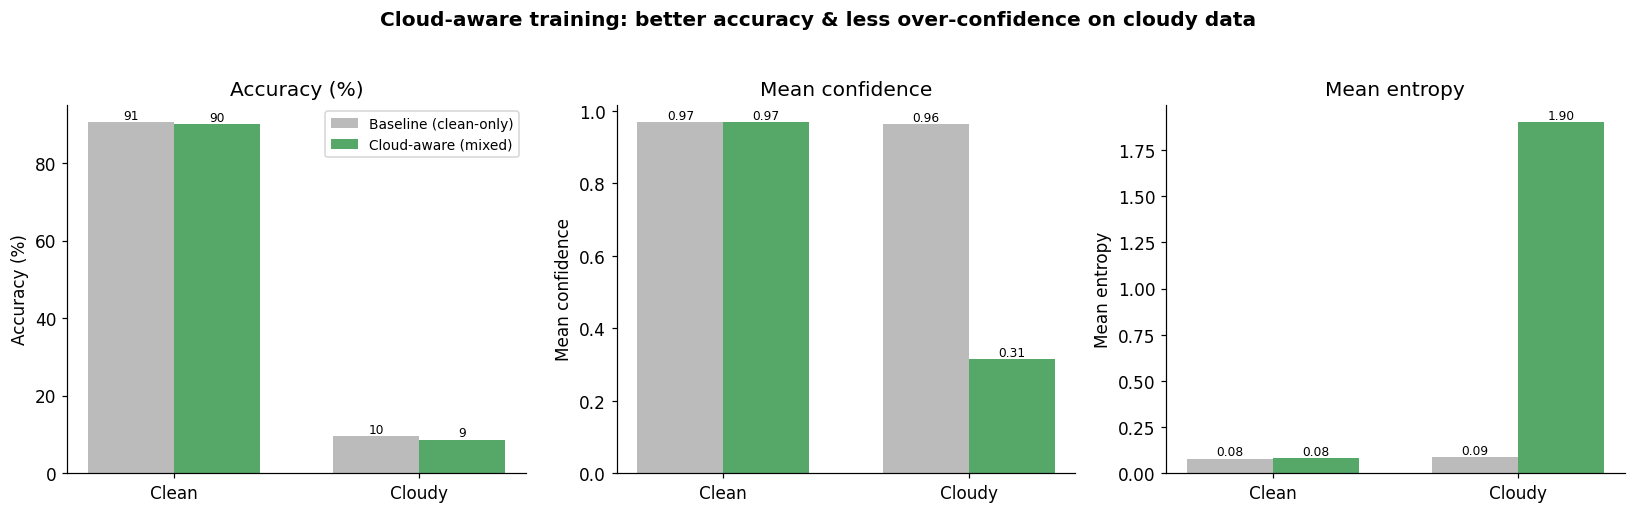

In [11]:
# ─── Baseline vs Cloud-aware: does mixed training help on cloudy data? ───────
groups  = ["clean", "cloudy"]
metrics = [("acc", "Accuracy (%)", 100), ("conf", "Mean confidence", 1), ("ent", "Mean entropy", 1)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x = np.arange(len(groups)); w = 0.35
for ax, (key, ylab, scale) in zip(axes, metrics):
    b = [results_baseline[g][key] * scale for g in groups]
    c = [results_cloud_aware[g][key] * scale for g in groups]
    ax.bar(x - w/2, b, w, color=GRAY,  label="Baseline (clean-only)")
    ax.bar(x + w/2, c, w, color=GREEN, label="Cloud-aware (mixed)")
    ax.set_xticks(x); ax.set_xticklabels([g.capitalize() for g in groups])
    ax.set(ylabel=ylab, title=ylab)
    for xi, v in zip(x - w/2, b):
        ax.text(xi, v, f"{v:.0f}" if scale == 100 else f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    for xi, v in zip(x + w/2, c):
        ax.text(xi, v, f"{v:.0f}" if scale == 100 else f"{v:.2f}", ha="center", va="bottom", fontsize=8)
axes[0].legend(fontsize=9)
plt.suptitle("Cloud-aware training: better accuracy & less over-confidence on cloudy data",
             fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

---
## 7  Uncertainty Visualisation on Individual Images


  Cloud=0%  Ensemble Acc=92.8% Conf=0.904 H_epi=0.157 | Baseline Acc=90.6% | Cloud-aware Acc=90.1%
  Cloud=15%  Ensemble Acc=21.9% Conf=0.498 H_epi=0.875 | Baseline Acc=21.1% | Cloud-aware Acc=18.0%
  Cloud=30%  Ensemble Acc=19.8% Conf=0.468 H_epi=0.928 | Baseline Acc=20.2% | Cloud-aware Acc=16.7%
  Cloud=45%  Ensemble Acc=14.9% Conf=0.490 H_epi=0.900 | Baseline Acc=17.8% | Cloud-aware Acc=14.3%
  Cloud=60%  Ensemble Acc=12.1% Conf=0.605 H_epi=0.692 | Baseline Acc=12.7% | Cloud-aware Acc=6.6%
  Cloud=75%  Ensemble Acc=6.2% Conf=0.649 H_epi=0.504 | Baseline Acc=12.1% | Cloud-aware Acc=13.1%
  Cloud=85%  Ensemble Acc=9.6% Conf=0.862 H_epi=0.213 | Baseline Acc=14.4% | Cloud-aware Acc=22.7%


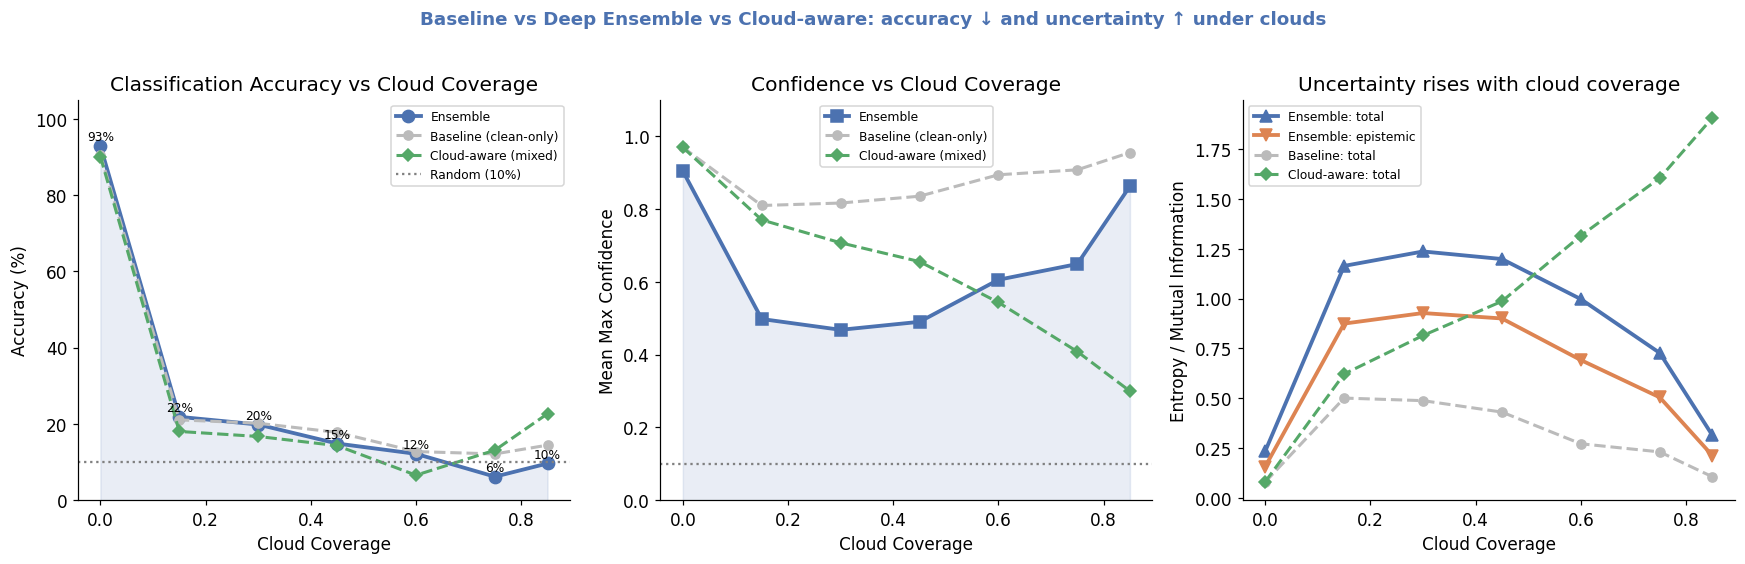

In [16]:
# ─── Baseline vs Ensemble vs Cloud-aware: sweep over cloud levels ────────────
cloud_levels = [0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.85]
e_accs, e_confs, e_ent_total, e_ent_epi = [], [], [], []

def _entropy(p, dim=-1):
    return -(p * p.clamp_min(1e-12).log()).sum(dim)

# Single-model overlays — only added if the model exists (no stale-global dependency)
single_models = {}
if "baseline_cnn"    in globals(): single_models["Baseline (clean-only)"] = dict(model=baseline_cnn,    color=GRAY,  fmt="o--")
if "cloud_aware_cnn" in globals(): single_models["Cloud-aware (mixed)"]   = dict(model=cloud_aware_cnn, color=GREEN, fmt="D--")
for info in single_models.values():
    info["model"].eval()
sweep = {n: dict(acc=[], conf=[], ent=[]) for n in single_models}

for cov in cloud_levels:
    corr, conf, ent_tot, ent_epi = [], [], [], []
    sm = {n: dict(corr=[], conf=[], ent=[]) for n in single_models}
    for xb, yb in test_loader_clean:
        if cov > 0:
            xb = add_clouds(xb, max_cov=cov, seed=42)
        xb_d = xb.to(device)
        member_p = ensemble_probs(ensemble, xb_d).cpu()            # (M, B, C)
        p_bar    = member_p.mean(0)                                # (B, C) predictive dist
        corr.append((p_bar.argmax(-1) == yb).float())
        conf.append(p_bar.max(-1).values)
        H_total = _entropy(p_bar)                                  # total / predictive
        H_alea  = _entropy(member_p).mean(0)                       # aleatoric (mean member entropy)
        ent_tot.append(H_total)
        ent_epi.append(H_total - H_alea)                           # epistemic = mutual information
        for n, info in single_models.items():
            with torch.no_grad():
                pr = F.softmax(info["model"](xb_d), dim=-1).cpu()
            sm[n]["corr"].append((pr.argmax(-1) == yb).float())
            sm[n]["conf"].append(pr.max(-1).values)
            sm[n]["ent"].append(_entropy(pr))                      # single model: predictive entropy only
    e_accs.append(torch.cat(corr).mean().item())
    e_confs.append(torch.cat(conf).mean().item())
    e_ent_total.append(torch.cat(ent_tot).mean().item())
    e_ent_epi.append(torch.cat(ent_epi).mean().item())
    for n in single_models:
        sweep[n]["acc"].append(torch.cat(sm[n]["corr"]).mean().item())
        sweep[n]["conf"].append(torch.cat(sm[n]["conf"]).mean().item())
        sweep[n]["ent"].append(torch.cat(sm[n]["ent"]).mean().item())
    line = f"  Cloud={cov:.0%}  Ensemble Acc={e_accs[-1]*100:.1f}% Conf={e_confs[-1]:.3f} H_epi={e_ent_epi[-1]:.3f}"
    for n in single_models:
        line += f" | {n.split()[0]} Acc={sweep[n]['acc'][-1]*100:.1f}%"
    print(line)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(cloud_levels, [a*100 for a in e_accs], "o-", color=BLUE, lw=2.5, ms=8, label="Ensemble")
ax.fill_between(cloud_levels, 0, [a*100 for a in e_accs], alpha=0.12, color=BLUE)
for n, info in single_models.items():
    ax.plot(cloud_levels, [a*100 for a in sweep[n]["acc"]], info["fmt"], color=info["color"], lw=2, ms=6, label=n)
ax.axhline(1/N_CLASSES*100, color="gray", ls=":", label=f"Random ({100/N_CLASSES:.0f}%)")
ax.set(xlabel="Cloud Coverage", ylabel="Accuracy (%)",
       title="Classification Accuracy vs Cloud Coverage", ylim=(0, 105))
for x, a in zip(cloud_levels, e_accs):
    ax.text(x, a*100+1.5, f"{a*100:.0f}%", ha="center", fontsize=8)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(cloud_levels, e_confs, "s-", color=BLUE, lw=2.5, ms=8, label="Ensemble")
ax.fill_between(cloud_levels, 0, e_confs, alpha=0.12, color=BLUE)
for n, info in single_models.items():
    ax.plot(cloud_levels, sweep[n]["conf"], info["fmt"], color=info["color"], lw=2, ms=6, label=n)
ax.axhline(1/N_CLASSES, color="gray", ls=":")
ax.set(xlabel="Cloud Coverage", ylabel="Mean Max Confidence",
       title="Confidence vs Cloud Coverage", ylim=(0, 1.1))
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(cloud_levels, e_ent_total, "^-", color=BLUE,   lw=2.5, ms=8, label="Ensemble: total")
ax.plot(cloud_levels, e_ent_epi,   "v-", color=ORANGE, lw=2.5, ms=8, label="Ensemble: epistemic")
for n, info in single_models.items():
    ax.plot(cloud_levels, sweep[n]["ent"], info["fmt"], color=info["color"], lw=2, ms=6, label=f"{n.split()[0]}: total")
ax.set(xlabel="Cloud Coverage", ylabel="Entropy / Mutual Information",
       title="Uncertainty rises with cloud coverage")
ax.legend(fontsize=8)

plt.suptitle("Baseline vs Deep Ensemble vs Cloud-aware: accuracy ↓ and uncertainty ↑ under clouds",
             color=BLUE, fontweight="bold", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Per-image uncertainty under increasing cloud

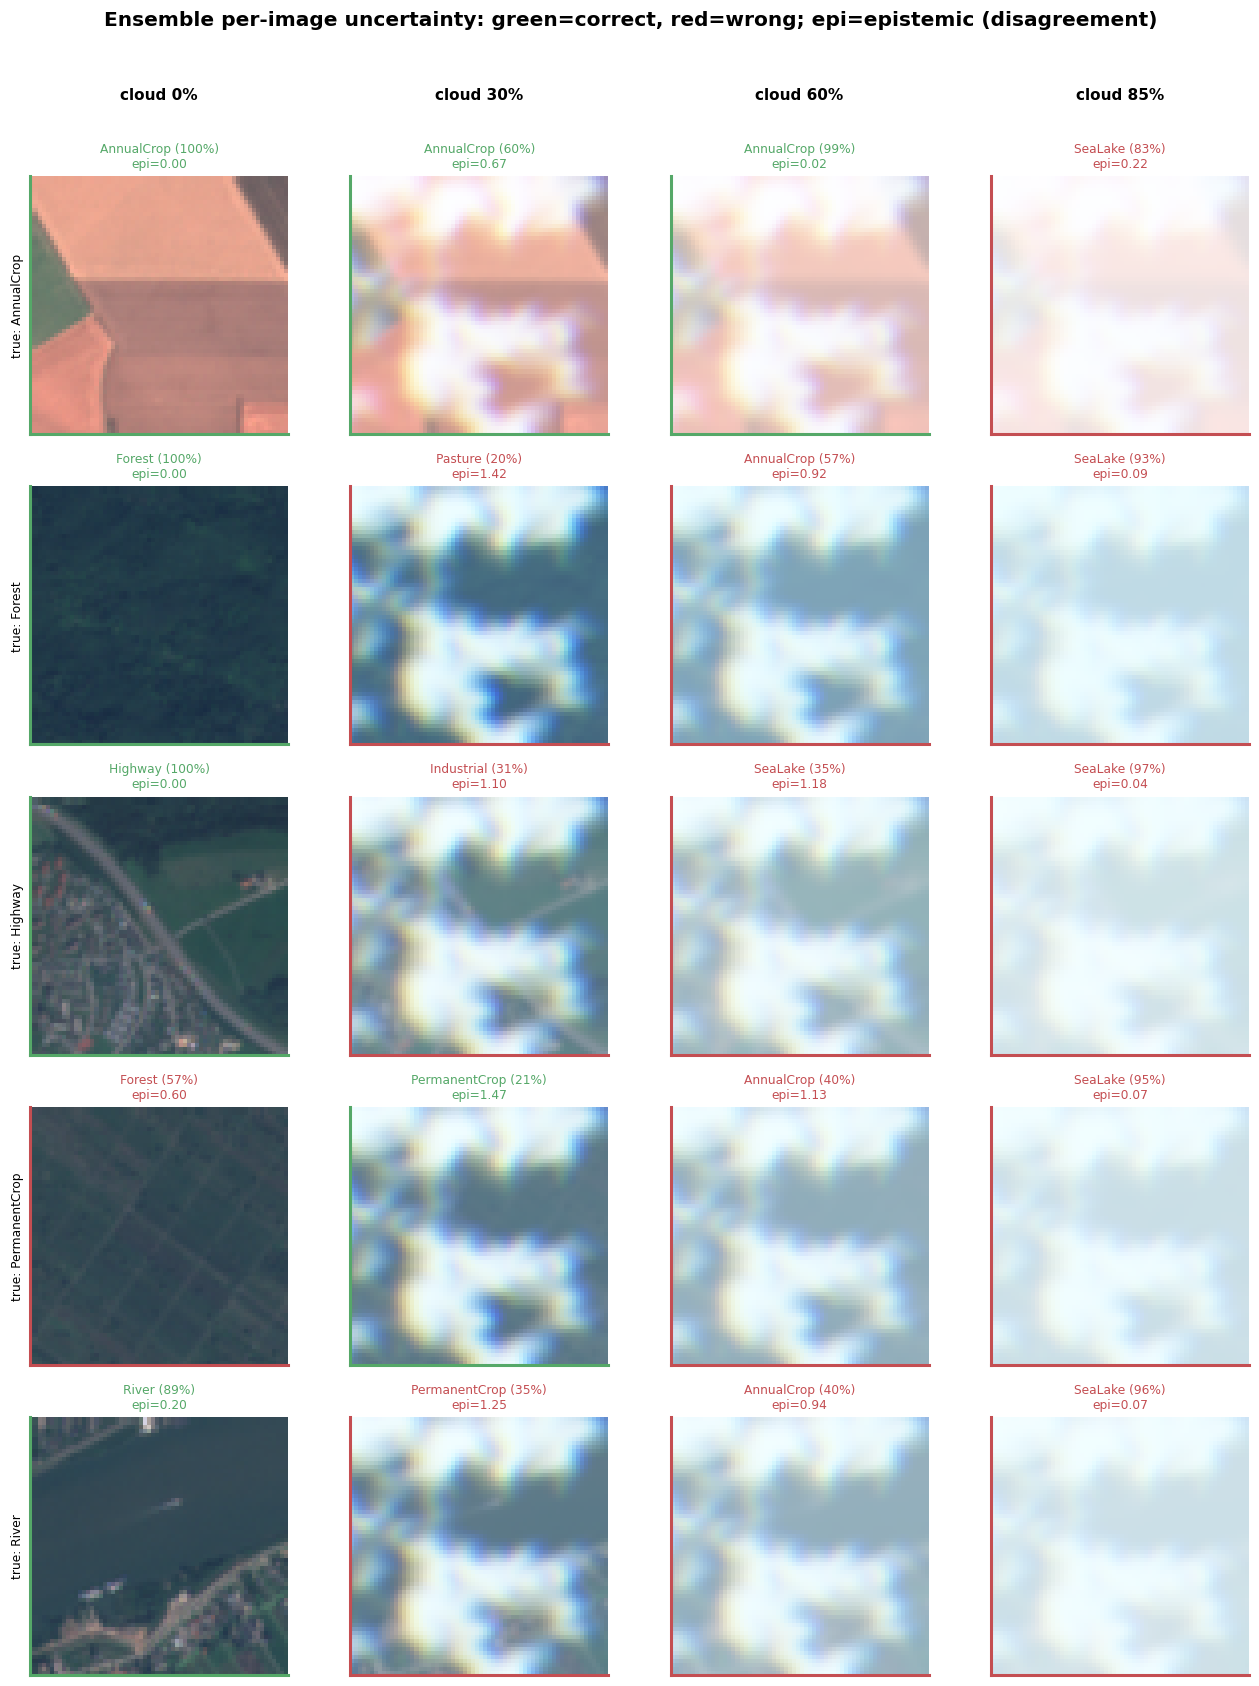

In [15]:
# ─── Per-image uncertainty: ensemble predictions under increasing cloud ──────
n   = len(test_imgs_clean)
sel = [int(f * n) for f in (0.02, 0.22, 0.42, 0.62, 0.82)]   # spread across classes
levels = [0.0, 0.30, 0.60, 0.85]

def _ent(p, dim=-1):
    return -(p * p.clamp_min(1e-12).log()).sum(dim)

fig, axes = plt.subplots(len(sel), len(levels), figsize=(len(levels) * 3, len(sel) * 3))
for r, idx in enumerate(sel):
    base = test_imgs_clean[idx:idx + 1]                       # (1, 3, 64, 64) normalised
    true = EUROSAT_CLASSES[test_lbls_clean[idx].item()]
    for c, cov in enumerate(levels):
        x = add_clouds(base, max_cov=cov, seed=7) if cov > 0 else base
        mp   = ensemble_probs(ensemble, x.to(device)).cpu()   # (M, 1, C)
        pbar = mp.mean(0)[0]                                   # (C,)
        pred = EUROSAT_CLASSES[pbar.argmax().item()]
        conf = pbar.max().item()
        epi  = (_ent(pbar) - _ent(mp[:, 0, :]).mean()).item()  # epistemic = mutual information
        ok   = (pred == true)
        ax = axes[r, c]
        ax.imshow(denorm(x)[0].permute(1, 2, 0).numpy().clip(0, 1))
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{pred} ({conf*100:.0f}%)\nepi={epi:.2f}", fontsize=8, color=(GREEN if ok else RED))
        for sp in ax.spines.values():
            sp.set_color(GREEN if ok else RED); sp.set_linewidth(2)
        if c == 0:
            ax.set_ylabel(f"true: {true}", fontsize=8)
for c, cov in enumerate(levels):
    axes[0, c].annotate(f"cloud {cov:.0%}", xy=(0.5, 1.30), xycoords="axes fraction",
                        ha="center", fontsize=10, fontweight="bold")
plt.suptitle("Ensemble per-image uncertainty: green=correct, red=wrong; epi=epistemic (disagreement)",
             fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()